# Cuaderno 1. Operaciones entre imagenes

**Procesamiento de Imagenes** — Universidad Diego Portales

---

## Desactivar el autocompletado por IA para un mejor entendimiento     

## Contenidos

| Subtema | Tema | Ejercicios |
|---|---|---|
| 1 | Suma de imagenes | 1.1 a 1.3 |
| 2 | Resta de imagenes | 2.1  |
| 3 | Promediado de imagenes | 3.1 y 3.2 |
| 4 | Multiplicacion y division | 4.1 |
| 5 | Operaciones logicas | 5.1 y 5.2 |
| 6 | Mezcla alfa y transicion cruzada | 6.1 |

Todas las imagenes provienen de `skimage.data`, de modo que el cuaderno se ejecuta sin descargas ni archivos externos. 

Se requiere `numpy`, `matplotlib`, `scikit-image`, `scipy` y `opencv-python`.

## Parte 0. Preliminares

Antes de operar con imagenes conviene fijar tres cosas: el tipo de dato, el rango de valores y una funcion de despliegue comun.

La regla que se aplica en todo el cuaderno es la misma que rige el resto del curso: **convertir a punto flotante al entrar, procesar en punto flotante, volver a entero de 8 bits solo para guardar o mostrar.** Casi todos los errores de esta unidad son violaciones de esa regla.

Tres convenciones de rango conviven y ninguna se autodescribe:

| Rango | Tipo | Donde aparece |
|---|---|---|
| $[0, 255]$ | `uint8` | archivos, camaras, visualizacion |
| $[0, 1]$ | `float64` | scikit-image, literatura |
| $[-1, 1]$ | `float32` | entrada tipica de redes neuronales |

`skimage.util.img_as_float` convierte al rango $[0,1]$ y `img_as_ubyte` vuelve a $[0,255]$ con saturacion. Nunca hay que confiar en la pantalla para verificar el rango, porque el visualizador normaliza automaticamente al minimo y maximo del arreglo: una imagen mal escalada puede verse perfecta y estar mal en memoria. Se verifica con `dtype`, `min()` y `max()`.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

from skimage import data, color, util, filters, morphology, measure, draw, transform
from scipy import ndimage as ndi

np.random.seed(0)
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["image.cmap"] = "gray"
plt.rcParams["axes.titlesize"] = 10


def mostrar(imagenes, titulos=None, cmap="gray", vmin=None, vmax=None, ancho=3.4):
    # Despliega una lista de imagenes en una fila, sin ejes
    n = len(imagenes)
    fig, axes = plt.subplots(1, n, figsize=(ancho * n, ancho * 1.05))
    if n == 1:
        axes = [axes]
    for ax, im in zip(axes, imagenes):
        if im.ndim == 3:
            ax.imshow(im)
        else:
            ax.imshow(im, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_axis_off()
    if titulos is not None:
        for ax, t in zip(axes, titulos):
            ax.set_title(t)
    plt.tight_layout()
    plt.show()


def describir(im, nombre="imagen"):
    # Imprime la informacion minima que hay que verificar antes de operar
    print(f"{nombre:22s} shape={str(im.shape):18s} dtype={str(im.dtype):10s} "
          f"min={im.min():.4g} max={im.max():.4g}")

In [4]:
# Verificacion rapida de las convenciones de rango
camera = data.camera()
describir(camera, "camera (uint8)")
describir(util.img_as_float(camera), "camera (float)")

camera (uint8)         shape=(512, 512)         dtype=uint8      min=0 max=255
camera (float)         shape=(512, 512)         dtype=float64    min=0 max=1


---

# Subtema 1. Suma de imagenes

## 1.1 El modelo puntual

Una operacion puntual entre dos imagenes produce una tercera cuyo valor en cada posicion depende unicamente de los valores en esa misma posicion:

$$g(x,y) = T\big[f_1(x,y),\, f_2(x,y)\big]$$

No hay vecindad involucrada. Esto tiene tres consecuencias que conviene enunciar de entrada:

1. **Requieren correspondencia geometrica.** Sumar o restar dos imagenes exige que el pixel $(x,y)$ de una y de otra observen el mismo punto de la escena. Si las imagenes no estan registradas, la operacion es aritmeticamente valida y fisicamente absurda. Este es el motivo por el cual el registro de imagenes, que se vera al final del curso, es un requisito previo y no un adorno.
2. **Son triviales de paralelizar** y por eso son la base de todo procesamiento en tiempo real, GPU y hardware embebido.
3. **El resultado suele salirse del rango representable.** Este es el problema central de la seccion siguiente.

## 1.2 El rango del resultado: envolvente y saturacion

Si $f_1, f_2 \in [0, 255]$, entonces:

| Operacion | Rango del resultado |
|---|---|
| $f_1 + f_2$ | $[0, 510]$ |
| $f_1 - f_2$ | $[-255, 255]$ |
| $f_1 \cdot f_2$ | $[0, 65025]$ |

Ninguno cabe en `uint8`. Hay dos politicas para resolverlo, y elegir mal es el error mas frecuente de esta unidad:

**Envolvente (wraparound).** El resultado se toma modulo 256. Es lo que hace NumPy cuando el arreglo es `uint8`. Asi, $200 + 100 = 44$. Un pixel muy claro puede volverse negro.

**Saturacion (clipping).** Todo lo que excede se fija en el extremo del rango. Es lo que hace OpenCV con `cv2.add`. Asi, $200 + 100 = 255$. Es el comportamiento fisicamente razonable: un sensor que recibe mas luz de la que puede registrar se satura, no se apaga.

La consecuencia practica es que `img1 + img2` y `cv2.add(img1, img2)` **no son la misma operacion**. La saturacion tampoco es inocua: destruye informacion de forma irreversible, porque todos los valores que superan el maximo quedan indistinguibles en 255. Trabajar en punto flotante pospone la decision hasta el momento de mostrar o guardar, que es donde corresponde tomarla.

### Ejercicio 1.1. Aumento de brillo

**Enunciado.** Aumente el brillo de `data.camera()` sumando la constante 60 de tres formas distintas: (a) directamente sobre el arreglo `uint8`, (b) con saturacion explicita, (c) operando en punto flotante y recortando al final. Muestre las tres imagenes y sus histogramas. Explique el patron que aparece en la version (a) e identifique que regiones de la imagen original lo producen.

#### SOLUCION — Ejercicio 1.1

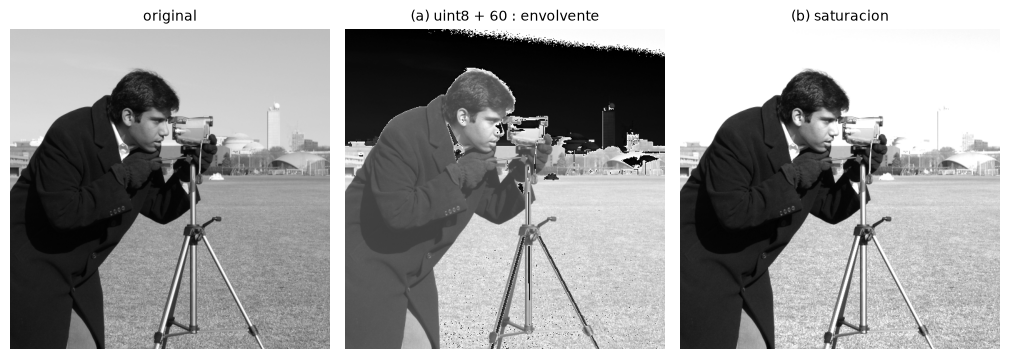

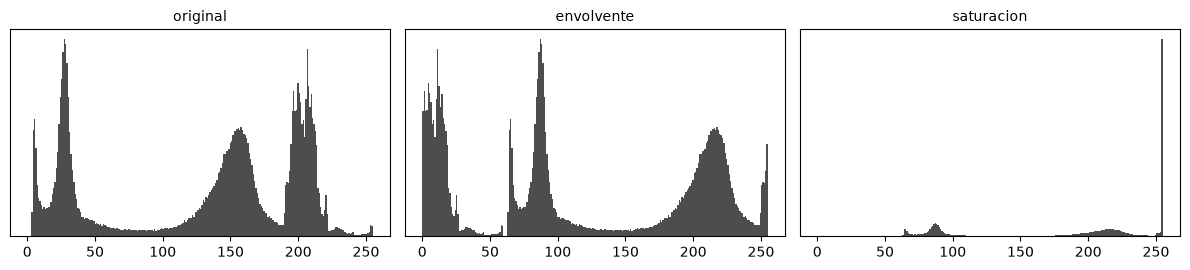

pixeles que exceden 255 al sumar 60: 72087
(a) y (b) coinciden en: 72.5% de los pixeles


In [5]:
# === SOLUCION Ejercicio 1.1 ===
im = data.camera()

# (a) NumPy sobre uint8: el resultado se calcula modulo 256
a = im + np.uint8(60)

# (b) saturacion: se calcula en int16 (que si admite valores > 255) y se recorta
b = np.clip(im.astype(np.int16) + 60, 0, 255).astype(np.uint8)


mostrar([im, a, b], ["original", "(a) uint8 + 60 : envolvente", "(b) saturacion"])

fig, axes = plt.subplots(1, 3, figsize=(12, 2.8))
for ax, x, t in zip(axes, [im, a, b], ["original", "envolvente", "saturacion"]):
    ax.hist(x.ravel(), bins=256, range=(0, 255), color="0.3")
    ax.set_title(t); ax.set_yticks([])
plt.tight_layout(); plt.show()

print("pixeles que exceden 255 al sumar 60:", int((im.astype(np.int16) + 60 > 255).sum()))
print("(a) y (b) coinciden en:", f"{(a == b).mean() * 100:.1f}% de los pixeles")

**Comentario.** En la version (a) el cielo y las zonas claras del abrigo aparecen con manchas oscuras: son exactamente los pixeles cuyo valor original superaba $195$, porque $195 + 60 = 255$ es el ultimo valor representable y a partir de ahi el resultado reinicia desde cero. El efecto es discontinuo, es decir, produce bordes falsos donde la imagen original era suave, y por eso resulta tan visible. Poco mas de un cuarto de la imagen esta afectado.

La version (b) es la que corresponde a la intencion fisica de la operacion. En el histograma se ve el mecanismo con claridad: la envolvente traslada la cola derecha del histograma al extremo izquierdo, mientras que la saturacion la acumula en una barra alta en 255. Esa barra es la senal caracteristica de una imagen sobreexpuesta o mal procesada, y conviene reconocerla.

### Ejercicio 1.2. Suma de dos imagenes

**Enunciado.** Sume `data.camera()` y `data.brick()`, recortadas al mismo tamano, de dos maneras: con `cv2.add` sobre `uint8` y en punto flotante sin recortar hasta el final. Compare tambien con la suma directa de NumPy sobre `uint8`. Determine que fraccion de los pixeles se satura y explique por que la suma de dos imagenes casi siempre requiere normalizacion.

#### SOLUCION — Ejercicio 1.2

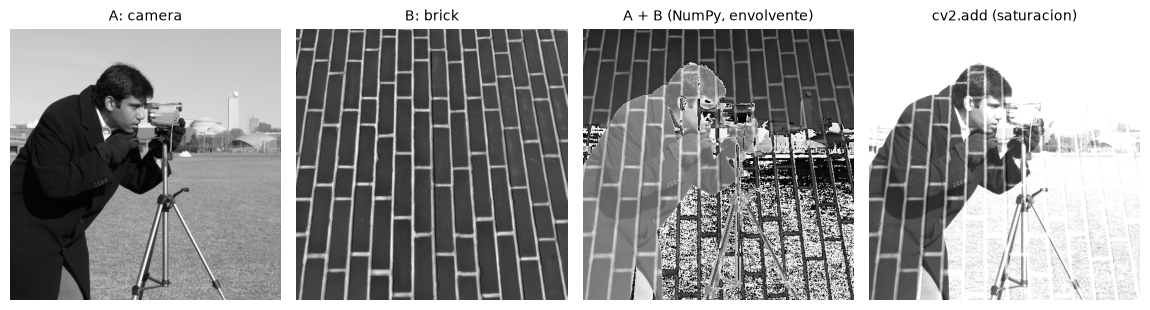

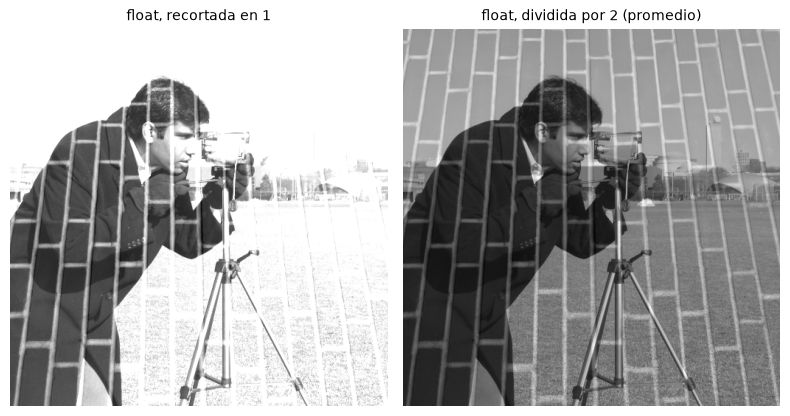

rango de la suma en flotante: [0.27, 1.76]
pixeles que exceden 1.0     : 50.2%
pixeles saturados por cv2.add: 50.9%


In [6]:
# === SOLUCION Ejercicio 1.2 ===
A = data.camera()[:512, :512]
B = data.brick()[:512, :512]

suma_numpy = A + B                       # uint8: envolvente
suma_cv2 = cv2.add(A, B)                 # uint8: saturacion

# En flotante la suma no se pierde; recien al final se decide como llevarla a [0, 1]
Af, Bf = util.img_as_float(A), util.img_as_float(B)
suma_float = Af + Bf                     # rango real [0, 2]
suma_recortada = np.clip(suma_float, 0, 1)
suma_normalizada = suma_float / 2.0      # equivale al promedio de las dos imagenes

mostrar([A, B, suma_numpy, suma_cv2],
        ["A: camera", "B: brick", "A + B (NumPy, envolvente)", "cv2.add (saturacion)"],
        ancho=2.9)
mostrar([suma_recortada, suma_normalizada],
        ["float, recortada en 1", "float, dividida por 2 (promedio)"], ancho=4.0)

print(f"rango de la suma en flotante: [{suma_float.min():.2f}, {suma_float.max():.2f}]")
print(f"pixeles que exceden 1.0     : {(suma_float > 1).mean() * 100:.1f}%")
print(f"pixeles saturados por cv2.add: {(suma_cv2 == 255).mean() * 100:.1f}%")

**Comentario.** Casi la mitad de los pixeles excede el rango, de modo que `cv2.add` los fija todos en 255 y la version recortada en flotante hace lo mismo: ambas producen una imagen con grandes zonas blancas planas, donde la informacion de las dos imagenes originales se perdio por igual. La suma de NumPy es peor todavia, porque en lugar de aplanar invierte: las zonas mas claras se vuelven oscuras y aparecen bordes inexistentes.

La division por dos conserva toda la informacion, porque el rango $[0,2]$ se mapea de vuelta a $[0,1]$ sin recortar nada. El precio es que cada imagen aporta la mitad de su contraste original.

De aqui la regla practica: **sumar dos imagenes con peso unitario casi nunca es lo que se quiere**. Lo que normalmente se busca es una combinacion cuyo resultado permanezca en el rango valido, es decir, una suma ponderada con pesos que sumen uno. Esa operacion es el blending, y es el tema del ejercicio siguiente.

## 1.3 Suma ponderada: blending

Para que el resultado de una suma se mantenga dentro del rango valido basta con exigir que los pesos sumen uno:

$$g = w\,f_1 + (1-w)\,f_2, \qquad w \in [0,1]$$

Como $f_1, f_2 \in [0,1]$ y los pesos son no negativos y suman uno, el resultado es una combinacion convexa y esta garantizado en $[0,1]$: no hay desbordamiento posible. El parametro $w$ controla cuanto aporta cada imagen, desde $w = 0$, que devuelve $f_2$ intacta, hasta $w = 1$, que devuelve $f_1$.

Esta operacion se conoce como **blending** o mezcla, y en OpenCV esta implementada como `cv2.addWeighted(f1, w, f2, 1-w, gamma)`, donde `gamma` es un desplazamiento aditivo opcional que aqui se deja en cero.

### Ejercicio 1.3. Blending entre dos imagenes

**Enunciado.** Construya la mezcla de `data.camera()` y `data.brick()` para $w \in \{0,\ 0.25,\ 0.5,\ 0.75,\ 1\}$. Verifique numericamente que el resultado nunca se sale del rango valido. Compare su implementacion en punto flotante con `cv2.addWeighted` y determine si ambas coinciden. Indique en que rango de $w$ ambas imagenes siguen siendo reconocibles.

#### SOLUCION — Ejercicio 1.3

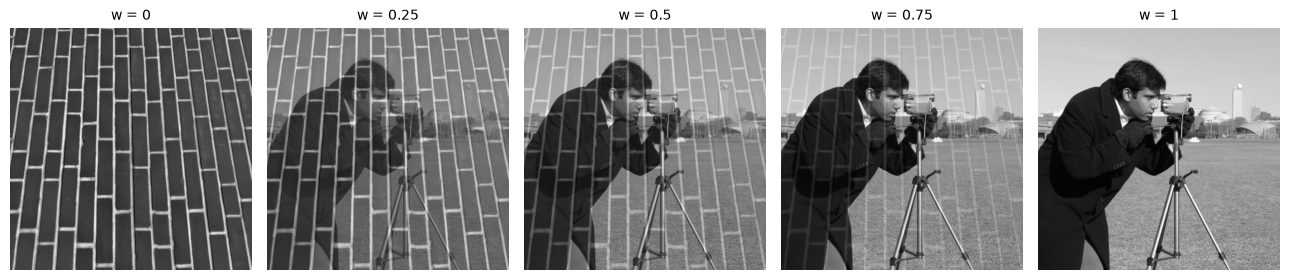

w = 0.00   rango del resultado = [0.247, 0.812]
w = 0.25   rango del resultado = [0.190, 0.824]
w = 0.50   rango del resultado = [0.133, 0.882]
w = 0.75   rango del resultado = [0.076, 0.941]
w = 1.00   rango del resultado = [0.000, 1.000]


In [7]:
# === SOLUCION Ejercicio 1.3 ===
A = util.img_as_float(data.camera()[:512, :512])
B = util.img_as_float(data.brick()[:512, :512])

pesos = [0, 0.25, 0.5, 0.75, 1]
mezclas = [w * A + (1 - w) * B for w in pesos]

mostrar(mezclas, [f"w = {w}" for w in pesos], ancho=2.6)

for w, g in zip(pesos, mezclas):
    print(f"w = {w:4.2f}   rango del resultado = [{g.min():.3f}, {g.max():.3f}]")

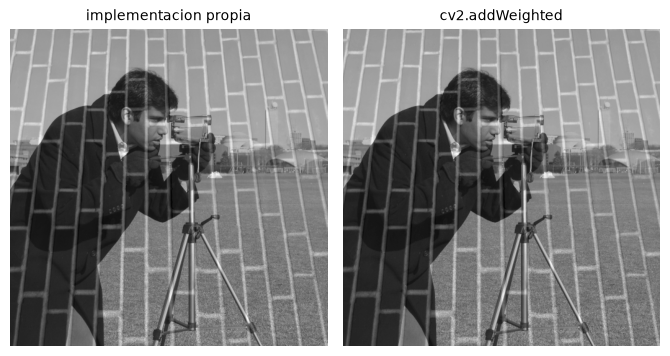

In [8]:
# === SOLUCION Ejercicio 1.3, comparacion con OpenCV ===
w = 0.5
propia = w * A + (1 - w) * B

# cv2.addWeighted opera sobre uint8; el ultimo argumento es el desplazamiento aditivo
opencv = cv2.addWeighted(data.camera()[:512, :512], w,
                         data.brick()[:512, :512], 1 - w, 0)

mostrar([propia, util.img_as_float(opencv)],["implementacion propia", "cv2.addWeighted"])

## Recreación del meme

Lea las imágenes de Harry Potter y haga la recreación del meme con diferentes valores de alpha:

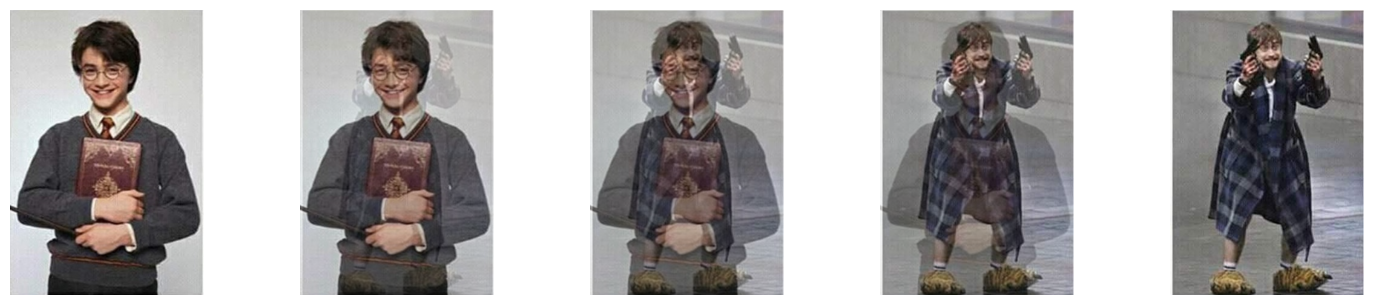

In [9]:
img_0 = cv2.cvtColor(cv2.imread("harry_potter_0.jpg"), cv2.COLOR_BGR2RGB)
img_1 = cv2.cvtColor(cv2.imread("harry_potter_1.jpg"), cv2.COLOR_BGR2RGB)

A = util.img_as_float(img_0)
B = util.img_as_float(img_1)

pesos_lineales = [1, 0.75, 0.5, 0.25, 0]
mezclas = [w * A + (1 - w) * B for w in pesos_lineales] 
mostrar(mezclas, ancho=3)


---

# Subtema 2. Resta de imagenes

## Restando imágenes

La resta responde a la pregunta de que cambio entre dos observaciones. Sus usos canonicos son la deteccion de movimiento entre cuadros consecutivos de un video, la sustraccion de fondo, donde $f_2$ es una imagen de referencia de la escena vacia, y la inspeccion industrial, donde $f_2$ es una pieza patron sin defectos.

El punto delicado es el signo. Una diferencia es una cantidad con signo, y almacenarla en un tipo sin signo elimina la mitad de la informacion. Hay tres formas de manejarlo y significan cosas distintas:

| Representacion | Formula | Interpretacion |
|---|---|---|
| Diferencia absoluta | $\lvert f_1 - f_2 \rvert$ | magnitud del cambio, sin direccion |
| Diferencia desplazada | $(f_1 - f_2)/2 + 0.5$ | preserva direccion, el gris medio es cambio nulo |
| Diferencia con signo | $f_1 - f_2$ en `float` | representacion correcta para calculo posterior |

Cual conviene depende de la pregunta. Si solo interesa **donde** hubo cambio, la diferencia absoluta basta y es lo que implementa `cv2.absdiff`. Si interesa **que tipo** de cambio, hay que conservar el signo: en deteccion de movimiento, el signo distingue la posicion nueva del objeto de la que dejo vacante.

La misma discusion reaparece en la semana de deteccion de bordes: un gradiente es una diferencia y tiene signo. Guardar la salida de Sobel en `uint8` recorta todos los negativos a cero y hace desaparecer la mitad de los bordes.

### Ejercicio 2.1. Deteccion de movimiento

**Enunciado.** A partir de dos capturas de una misma escena tomadas con la camara fija, en las que un objeto cambio de posicion, determine que zona se movio. El procedimiento tiene cuatro pasos: calcular la diferencia entre ambas capturas, umbralizarla para obtener la mascara de cambio, separar mediante el signo la posicion nueva de la antigua, y usar esa mascara para extraer el objeto de la segunda captura.
El resultado esperado es una diferencia practicamente nula en todo el fondo y dos regiones activas con el contorno del objeto: una positiva donde el objeto esta ahora y otra negativa donde estaba antes.

#### SOLUCION — Ejercicio 2.1

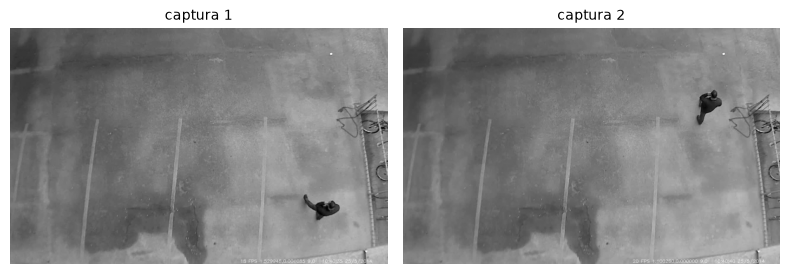

In [10]:
# === SOLUCION Ejercicio 2.1, construccion del par ===
# Reemplazar por rutas propias para usar imagenes reales:
from skimage import io
RUTA_1, RUTA_2 = "image-0323.jpg", "image-0417.jpg"

frame1 = util.img_as_float(color.rgb2gray(io.imread(RUTA_1)))
frame2 = util.img_as_float(color.rgb2gray(io.imread(RUTA_2)))

mostrar([frame1, frame2], ["captura 1", "captura 2"], ancho=4.0)

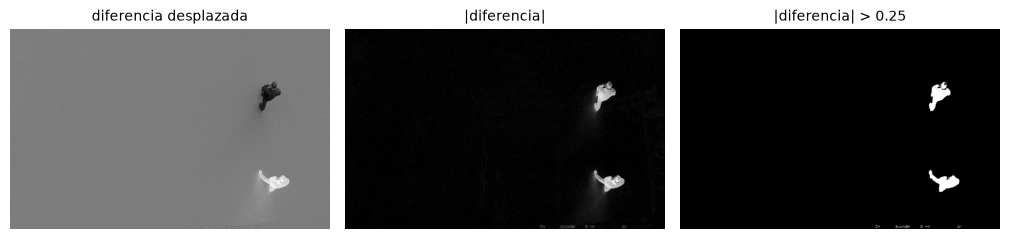

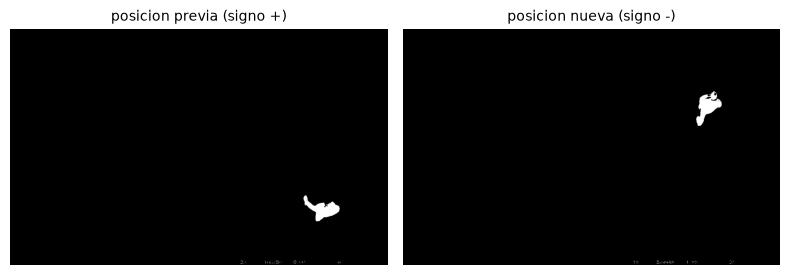

In [11]:
# === SOLUCION Ejercicio 2.1, deteccion ===
diferencia = frame2 - frame1                 # con signo, en flotante
magnitud = np.abs(diferencia)

UMBRAL = 0.25
cambio = magnitud > UMBRAL                   # donde hubo cambio, sin distinguir tipo

# El signo separa las dos regiones: aparicion frente a desaparicion
aparecio = diferencia > UMBRAL               # el objeto esta aqui en la captura 2
desaparecio = diferencia < -UMBRAL           # el objeto estaba aqui en la captura 1

mostrar([diferencia / 2 + 0.5, magnitud, cambio],
        ["diferencia desplazada", "|diferencia|", f"|diferencia| > {UMBRAL}"])
mostrar([aparecio, desaparecio], ["posicion previa (signo +)", "posicion nueva (signo -)"],
        ancho=4.0)

**Comentario.** El procedimiento localiza el objeto sin conocer nada sobre su forma ni su color: solo se apoya en que el fondo es identico en ambas capturas. Esa es la fortaleza y a la vez la fragilidad del metodo.

El uso del signo es lo que convierte una deteccion de cambio en una deteccion de movimiento. La diferencia absoluta marca dos regiones y no permite saber cual corresponde a la posicion actual; conservando el signo, la region positiva indica donde el objeto esta ahora, porque en la captura 2 esos pixeles se volvieron mas claros al ser ocupados por un objeto claro. Si el objeto fuera mas oscuro que el fondo, la relacion se invierte, de modo que el criterio depende del contraste y no es universal.

Sobre el umbral: aqui es holgado porque el par es tomado en las mismas condiciones y el fondo es muy similar. Sin embargo el fondo nunca se repite, por el ruido del sensor y por microvibraciones, y el umbral debe fijarse **en terminos del ruido del fondo y no del contraste del objeto**, tipicamente entre tres y cinco veces la desviacion del residuo medida sobre un par de capturas sin cambios. Ese es el calibrado que hay que hacer al usar imagenes propias.

#### SOLUCION — Ejercicio 2.2

---

# Subtema 3. Promediado de imagenes

Si una escena estatica se captura $N$ veces, cada captura contiene la misma senal y una realizacion distinta del ruido:

$$g_i(x,y) = f(x,y) + \eta_i(x,y)$$

Al promediar, la senal se conserva porque es identica en todas las capturas, mientras que el ruido tiende a cancelarse porque sus realizaciones son independientes y de media nula:

$$\bar{g}(x,y) = \frac{1}{N}\sum_{i=1}^{N} g_i(x,y), \qquad \sigma_{\bar{g}} = \frac{\sigma}{\sqrt{N}}$$

La reduccion es proporcional a $\sqrt{N}$: **cuadruplicar el numero de capturas duplica la calidad**. Ese rendimiento decreciente explica por que el promediado se abandona a partir de cierto punto en favor del filtrado espacial, que reduce ruido a partir de una sola imagen a cambio de perder resolucion.

Dos condiciones son indispensables. La primera es que el ruido sea independiente entre capturas: cualquier componente sistematica, como el ruido de patron fijo o la corriente oscura, no se promedia y sobrevive intacta. La segunda es que la escena no cambie, porque si algo se mueve, el promedio lo difumina en lugar de limpiarlo. Esa segunda propiedad, que aqui es una limitacion, se aprovecha en el ejercicio 3.2.



Una advertencia de implementacion: el acumulador **no puede ser `uint8`**. La suma de dos imagenes de 8 bits ya desborda, y la division entera trunca. Hay que acumular en `float` o en un entero suficientemente ancho.

### Ejercicio 3.1. Reduccion de ruido por promediado

**Enunciado.** Sobre `data.camera()`, genere $N$ capturas ruidosas agregando ruido gaussiano de media nula y desviacion $\sigma = 0.15$. Promedie las primeras $N$ capturas para $N = 1, 2, 4, 8, 16, 32, 64$ y mida la desviacion del residuo respecto de la imagen limpia. Grafique el resultado junto a la curva teorica $\sigma/\sqrt{N}$. 

#### SOLUCION — Ejercicio 3.1

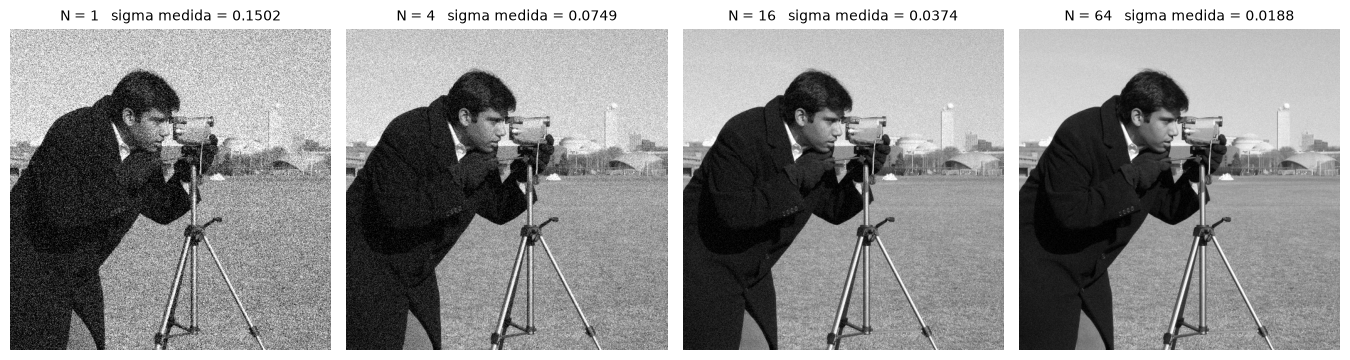

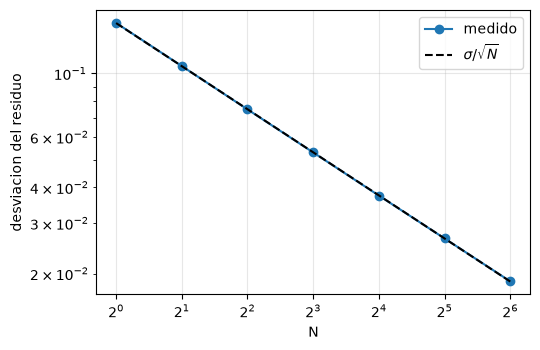

In [12]:
# === SOLUCION Ejercicio 3.1 ===
f = util.img_as_float(data.camera())
sigma = 0.15
Ns = [1, 2, 4, 8, 16, 32, 64]

rng = np.random.default_rng(0)
capturas = [f + rng.normal(0, sigma, f.shape) for _ in range(max(Ns))]

medidas, promedios = [], {}
for N in Ns:
    prom = np.mean(capturas[:N], axis=0)      # np.mean acumula en float64
    promedios[N] = prom
    medidas.append(np.std(prom - f))          # desviacion del residuo

mostrar([np.clip(promedios[n], 0, 1) for n in [1, 4, 16, 64]],
        [f"N = {n}   sigma medida = {np.std(promedios[n] - f):.4f}" for n in [1, 4, 16, 64]])

plt.figure(figsize=(5.5, 3.6))
plt.plot(Ns, medidas, "o-", label="medido")
plt.plot(Ns, sigma / np.sqrt(Ns), "k--", label=r"$\sigma/\sqrt{N}$")
plt.xscale("log", base=2); plt.yscale("log")
plt.xlabel("N"); plt.ylabel("desviacion del residuo"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

**Comentario.** La medicion empirica sigue la curva teorica con precision en todo el rango: al pasar de $N=1$ a $N=64$ la desviacion del residuo cae en un factor cercano a ocho, que es $\sqrt{64}$. Visualmente la mejora es evidente entre 1 y 16 capturas y mucho menos apreciable entre 16 y 64, que es la traduccion perceptual del rendimiento decreciente.



### Ejercicio 3.2. Estimacion del fondo por promediado

**Enunciado.** El promediado difumina lo que se mueve y conserva lo que permanece. Esa propiedad permite estimar el fondo de una escena a partir de varias capturas con objetos en movimiento, sin necesidad de una captura de la escena vacia. Use la imagen `fondo.jpg` como fondo real y las imagenes dentro de la carpeta `movimiento/` como la secuencia de prueba. Promedie los cuadros de la secuencia, compare el resultado con el fondo real y use ese fondo estimado para detectar el objeto en una de las capturas.


#### SOLUCION — Ejercicio 3.2


100%|██████████| 25/25 [00:00<00:00, 133.20it/s]


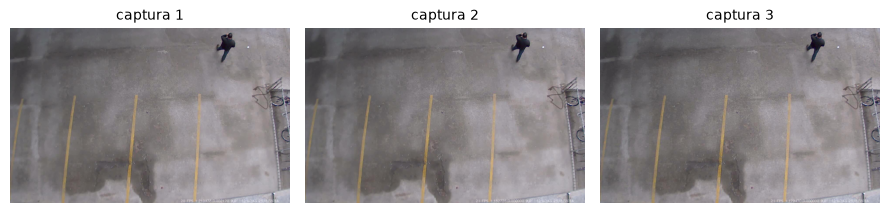

In [ ]:
# === SOLUCION Ejercicio 3.2, generacion de la secuencia ===
from pathlib import Path
from skimage import io, color, util
from tqdm import tqdm

base = Path(".")

def cargar_gris(path):
    im = io.imread(path)
    if im.ndim == 3 and im.shape[-1] == 3:
        return util.img_as_float(color.rgb2gray(im))
    return util.img_as_float(im)

fondo_real = cargar_gris(base / "fondo.jpg")
# Considerando las últimas 250 imágenes
secuencia = [cargar_gris(p) for p in tqdm(sorted((base / "movimiento").glob("*.jpg"))[475:])]

mostrar(secuencia[:3], [f"captura {i+1}" for i in range(3)], ancho=3.0)


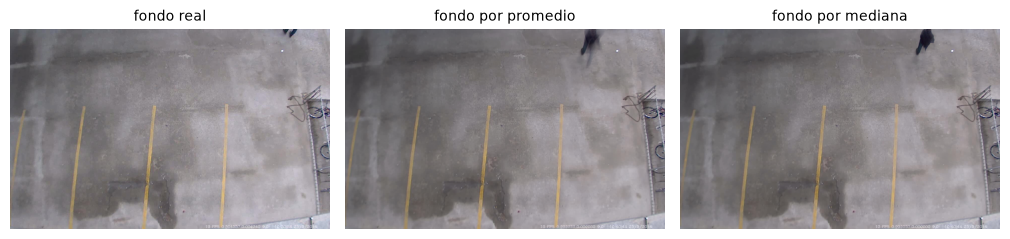

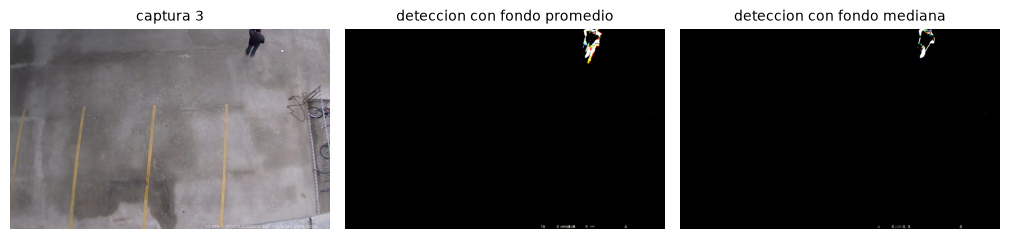

In [15]:
# === SOLUCION Ejercicio 3.2, estimacion y uso del fondo ===
fondo_promedio = np.mean(secuencia, axis=0)
fondo_mediana = np.median(secuencia, axis=0)      # alternativa robusta

mostrar([fondo_real, fondo_promedio, fondo_mediana],
        ["fondo real", "fondo por promedio", "fondo por mediana"])

# El fondo estimado permite detectar el objeto en cualquier captura de la secuencia
captura = secuencia[10]
deteccion_prom = np.abs(captura - fondo_promedio) > 0.10
deteccion_med = np.abs(captura - fondo_mediana) > 0.10

mostrar([captura, deteccion_prom, deteccion_med],
        ["captura 3", "deteccion con fondo promedio", "deteccion con fondo mediana"])


**Comentario.** El fondo fijo de `fondo.jpg` se conserva al promediar porque aparece igual en todas las capturas, mientras que el objeto en movimiento se difumina porque cambia de posicion entre cuadros (puede ver el difuminado usando pocas imágenes). En cada pixel, el fondo aporta un valor casi constante y el objeto solo contamina unas pocas imagenes, de modo que su influencia en el promedio queda atenuada. La mediana funciona mejor porque descarta valores atipicos: la mayoria de observaciones corresponden al fondo y una minoría al objeto, y la mediana recupera justamente ese valor dominante.

En la secuencia real de `movimiento/`, el movimiento no es artificial: el objeto aparece en distintas posiciones y el fondo queda estable. Eso hace que la estimacion del fondo sea una aproximacion directa del modelo de fondo que se desea mantener en vigilancia, mientras que un elemento que permanezca quieto durante varias imagenes se vuelve indistinguible del fondo. Es exactamente la misma logica que se usa en sistemas de video para mantener un fondo de referencia y luego detectar movimiento por diferencia.



---

# Subtema 4. Multiplicacion y division

## 4.1 Enmascaramiento

Multiplicar por una imagen binaria selecciona una region de interes y anula el resto:

$$g(x,y) = f(x,y) \cdot m(x,y), \qquad m(x,y) \in \{0, 1\}$$

Es la operacion que restringe cualquier calculo posterior, un histograma, una media, una segmentacion, a una region determinada. La mascara puede provenir de una segmentacion previa o construirse geometricamente.

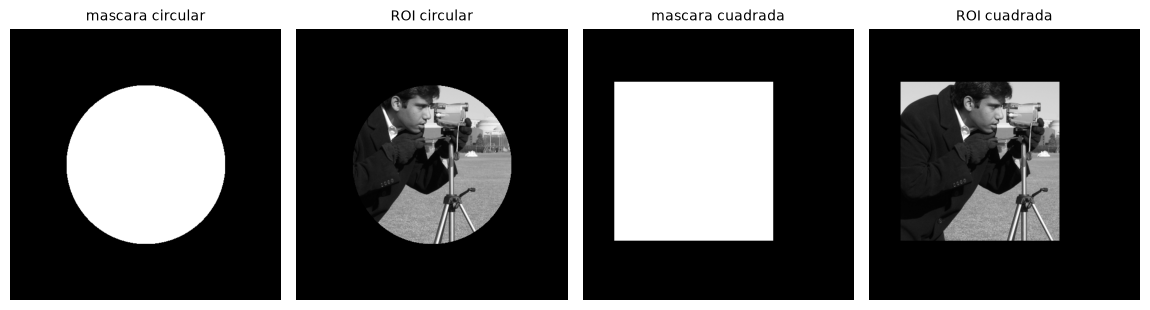

In [16]:
# Ejemplo: mascara binaria construida geometricamente
im = util.img_as_float(data.camera())
h, w = im.shape

# draw.disk devuelve los indices de los pixeles dentro del circulo
mascara_circulo = np.zeros((h, w), dtype=bool)
rr, cc = draw.disk((h // 2, w // 2), 150, shape=(h, w))
mascara_circulo[rr, cc] = True

mascara_cuadrado = np.zeros((h, w), dtype=bool)
mascara_cuadrado[100:400, 60:360] = True

mostrar([mascara_circulo, im * mascara_circulo, mascara_cuadrado, im * mascara_cuadrado],
        ["mascara circular", "ROI circular", "mascara cuadrada", "ROI cuadrada"], ancho=2.9)



Notese que para calcular estadisticas se indexa con la mascara, `im[mascara]`, y no se multiplica: multiplicar reemplaza el exterior por ceros, que luego entrarian en el promedio y lo sesgarian hacia abajo. La multiplicacion sirve para **visualizar** o para alimentar una operacion posterior; la indexacion sirve para **medir**.

## 4.2 Enmascaramiento continuo

Si la mascara toma valores intermedios, $\alpha(x,y) \in [0,1]$, la transicion entre region seleccionada y excluida deja de ser abrupta. La operacion natural es entonces combinar dos imagenes en lugar de anular una:

$$g = \alpha \, f_1 + (1 - \alpha)\, f_2$$

que es el blending del subtema 1, pero con el peso variando pixel a pixel en vez de ser una constante. Cuando $f_2$ es negro, se recupera el enmascaramiento simple con bordes suaves; cuando $f_2$ es otra imagen, se obtiene una composicion.

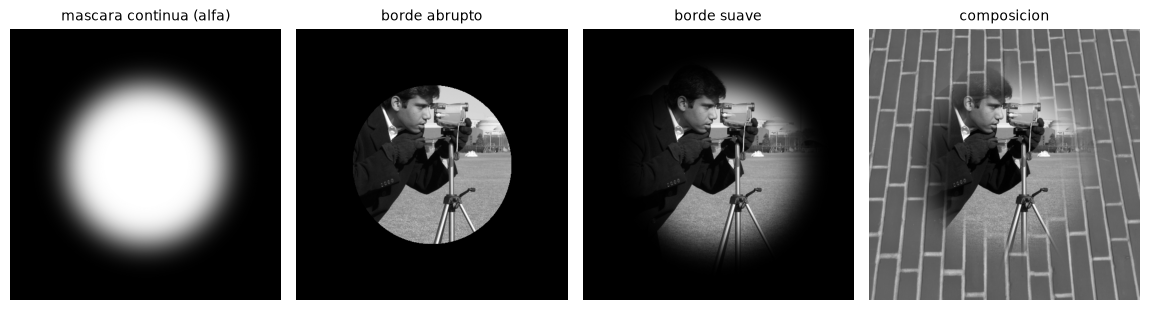

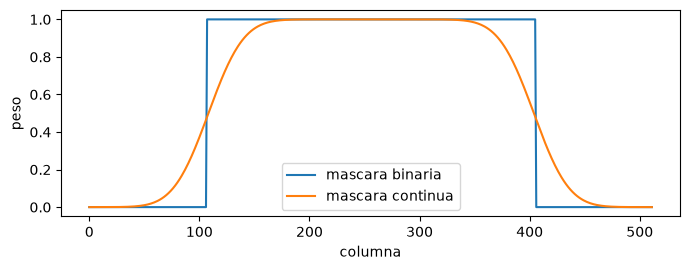

In [17]:
# Ejemplo: mascara continua obtenida suavizando una mascara binaria
alfa = filters.gaussian(mascara_circulo.astype(float), sigma=25)
fondo_negro = np.zeros_like(im)
otra_imagen = util.img_as_float(data.brick()[:h, :w])

vineteado       = alfa * im + (1 - alfa) * fondo_negro     # transicion suave hacia el negro
composicion     = alfa * im + (1 - alfa) * otra_imagen   # transicion hacia otra imagen

mostrar([alfa, im * mascara_circulo, vineteado, composicion],
        ["mascara continua (alfa)", "borde abrupto", "borde suave", "composicion"],
        ancho=2.9)

# Perfil horizontal por el centro: muestra la diferencia entre ambos bordes
plt.figure(figsize=(7, 2.8))
plt.plot(mascara_circulo[h // 2].astype(float), label="mascara binaria")
plt.plot(alfa[h // 2], label="mascara continua")
plt.xlabel("columna"); plt.ylabel("peso"); plt.legend(); plt.tight_layout(); plt.show()

## 4.3 Division: el modelo multiplicativo de iluminacion

La imagen observada es el producto de la iluminacion incidente por la reflectancia de la superficie:

$$f(x,y) = i(x,y) \cdot r(x,y)$$

donde $r \in [0,1]$ es propiedad del objeto e $i$ es propiedad de la escena. Casi siempre lo que interesa medir es $r$, y lo que estorba es $i$. Como el modelo es multiplicativo, **la correccion correcta es una division y no una resta**:

$$\hat{r}(x,y) = \frac{f(x,y)}{\hat{i}(x,y)}$$

La iluminacion se estima suavizando la propia imagen con un filtro de soporte mucho mayor que los objetos de interes: lo que sobrevive a ese suavizado es la componente de baja frecuencia, que es la iluminacion. Si es posible capturar una imagen de campo plano, es decir, una superficie uniforme bajo la misma iluminacion, esa imagen es $\hat{i}$ directamente y la estimacion resulta mucho mejor.

### Ejercicio 4.3. Correccion de iluminacion no uniforme

**Enunciado.** La imagen `data.page()` es un texto impreso capturado con iluminacion marcadamente desigual. Estime la componente de iluminacion suavizando la imagen con un filtro gaussiano de radio grande y corrija la imagen de dos maneras, por resta y por division. Binarice el texto en ambos casos con un umbral global y determine cual de las dos correcciones es consistente con el modelo de formacion de imagen. Justifique con los histogramas.

#### SOLUCION — Ejercicio 4.3

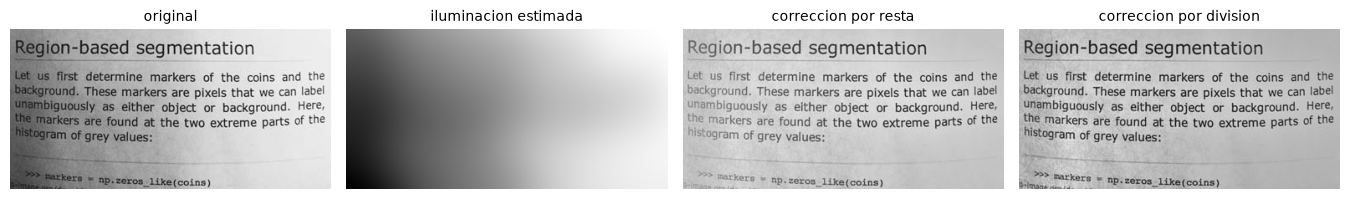

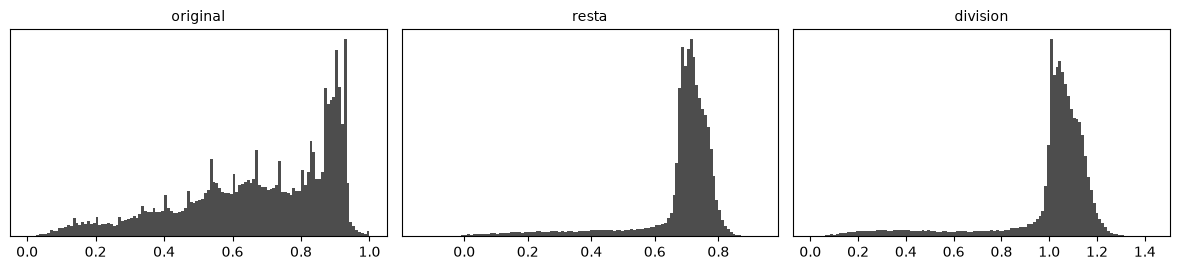

In [18]:
pagina = util.img_as_float(data.page())
# sigma debe ser mucho mayor que el ancho de un caracter, para que el texto
# no entre en la estimacion del fondo y se cancele a si mismo
iluminacion = filters.gaussian(pagina, sigma=25)

por_resta = pagina - iluminacion + iluminacion.mean()
por_division = pagina / (iluminacion + 1e-6)          # el epsilon evita dividir por cero

mostrar([pagina, iluminacion, por_resta, np.clip(por_division, 0, 1.5) / 1.5],
        ["original", "iluminacion estimada", "correccion por resta", "correccion por division"])

fig, axes = plt.subplots(1, 3, figsize=(12, 2.8))
for ax, x, t in zip(axes, [pagina, por_resta, por_division],
                    ["original", "resta", "division"]):
    ax.hist(x.ravel(), bins=120, color="0.3")
    ax.set_title(t); ax.set_yticks([])
plt.tight_layout(); plt.show()

original   umbral = 0.615   fraccion de tinta = 0.357
resta      umbral = 0.499   fraccion de tinta = 0.099
division   umbral = 0.736   fraccion de tinta = 0.107


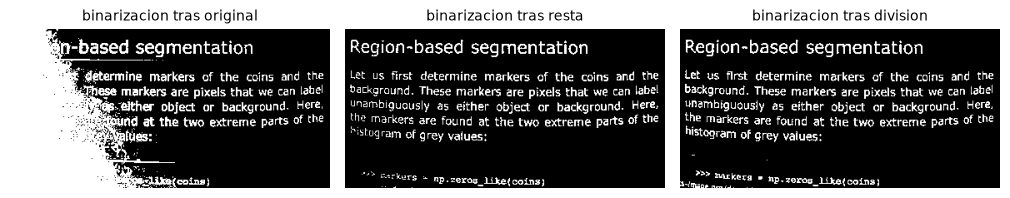

In [19]:
resultados = {}
for nombre, x in [("original", pagina), ("resta", por_resta), ("division", por_division)]:
    t = filters.threshold_otsu(x)
    resultados[nombre] = x < t               # el texto es oscuro
    print(f"{nombre:10s} umbral = {t:.3f}   fraccion de tinta = {resultados[nombre].mean():.3f}")

mostrar(list(resultados.values()), [f"binarizacion tras {k}" for k in resultados])

---

# Subtema 5. Operaciones logicas

## Operaciones sobre máscaras

Sobre imagenes binarias, las operaciones logicas son operaciones de conjuntos. Si $A$ y $B$ son los conjuntos de pixeles verdaderos:

| Operacion | NumPy | Conjunto | Lectura |
|---|---|---|---|
| Interseccion | `A & B` | $A \cap B$ | lo que ambas afirman |
| Union | `A \| B` | $A \cup B$ | lo que alguna afirma |
| Diferencia simetrica | `A ^ B` | $(A \setminus B) \cup (B \setminus A)$ | donde discrepan |
| Complemento | `~A` | $A^c$ | lo que A niega |
| Diferencia | `A & ~B` | $A \setminus B$ | lo que A afirma y B no |

La ultima fila merece atencion especial. Si $A$ es una segmentacion y $B$ la verdad de terreno, entonces $A \setminus B$ son los falsos positivos, $B \setminus A$ los falsos negativos y $A \oplus B$ el conjunto completo de errores. Sobre esas cantidades se define el indice de Jaccard, mas conocido como **IoU**:

$$\mathrm{IoU}(A,B) = \frac{|A \cap B|}{|A \cup B|}$$

es decir, una razon entre dos operaciones logicas. Vale 1 cuando las dos mascaras coinciden exactamente y 0 cuando son disjuntas. Es la medida estandar para evaluar una segmentacion y reaparecera en el cuaderno correspondiente.

Conviene tener presente el principio de inclusion y exclusion, que relaciona los tres conjuntos:

$$|A \cup B| = |A| + |B| - |A \cap B|$$

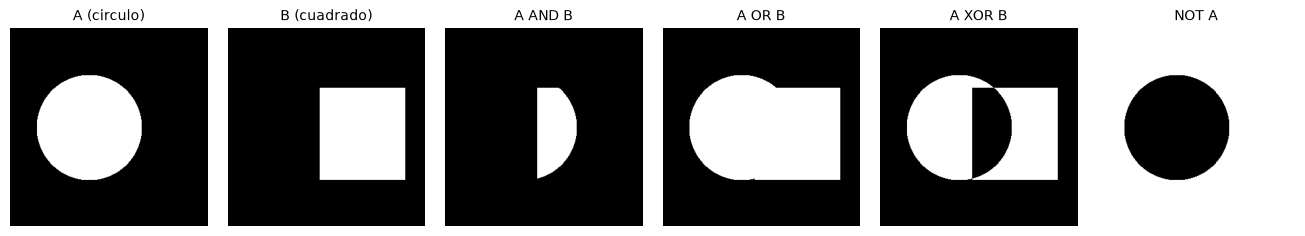

|A| = 20069,  |B| = 18200
|A n B| = 6620,  |A U B| = 31649
inclusion-exclusion: |A| + |B| - |A n B| = 31649
IoU = 0.2092
Dice = 0.3460


In [20]:
# Ejemplo: operaciones logicas sobre dos mascaras artificiales
lado = 300
A = np.zeros((lado, lado), dtype=bool)
B = np.zeros((lado, lado), dtype=bool)

rr, cc = draw.disk((150, 120), 80, shape=A.shape)      # circulo
A[rr, cc] = True
B[90:230, 140:270] = True                              # cuadrado

mostrar([A, B, A & B, A | B, A ^ B, ~A],
        ["A (circulo)", "B (cuadrado)", "A AND B", "A OR B", "A XOR B", "NOT A"],
        ancho=2.2)

inter, union = (A & B).sum(), (A | B).sum()
print(f"|A| = {A.sum()},  |B| = {B.sum()}")
print(f"|A n B| = {inter},  |A U B| = {union}")
print(f"inclusion-exclusion: |A| + |B| - |A n B| = {A.sum() + B.sum() - inter}")
print(f"IoU = {inter / union:.4f}")
print(f"Dice = {2 * inter / (A.sum() + B.sum()):.4f}")

### Ejercicio 5.1. IoU en funcion del solapamiento

**Enunciado.** Construya dos mascaras circulares artificiales del mismo radio y desplace una respecto de la otra. Para desplazamientos entre 0 y 200 pixeles, calcule y grafique el IoU y el coeficiente de Dice. Determine a que desplazamiento el IoU cae a la mitad y verifique numericamente la relacion entre ambos indices.

#### SOLUCION — Ejercicio 5.1

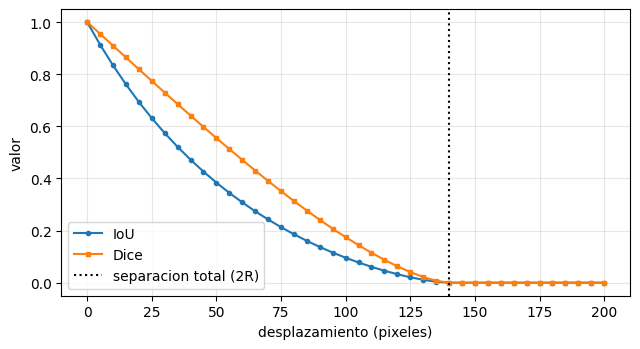

IoU = 0.5 se alcanza a un desplazamiento de 35 pixeles (25% del diametro)


In [26]:
# === SOLUCION Ejercicio 5.1 ===
lado, RADIO = 400, 70

def circulo(centro_col, centro_fila=200, radio=RADIO):
    m = np.zeros((lado, lado), dtype=bool)
    rr, cc = draw.disk((centro_fila, centro_col), radio, shape=m.shape)
    m[rr, cc] = True
    return m

A = circulo(150)
desplazamientos = np.arange(0, 201, 5)
ious, dices = [], []

for d in desplazamientos:
    B = circulo(150 + d)
    inter, union = (A & B).sum(), (A | B).sum()
    ious.append(inter / union)
    dices.append(2 * inter / (A.sum() + B.sum()))

ious, dices = np.array(ious), np.array(dices)

plt.figure(figsize=(6.5, 3.6))
plt.plot(desplazamientos, ious, "o-", ms=3, label="IoU")
plt.plot(desplazamientos, dices, "s-", ms=3, label="Dice")
plt.axvline(2 * RADIO, color="k", ls=":", label="separacion total (2R)")
plt.xlabel("desplazamiento (pixeles)"); plt.ylabel("valor")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

d_mitad = desplazamientos[np.argmin(np.abs(ious - 0.5))]
print(f"IoU = 0.5 se alcanza a un desplazamiento de {d_mitad} pixeles "
      f"({d_mitad / (2 * RADIO) * 100:.0f}% del diametro)")

  despl.      IoU     Dice   2*IoU/(1+IoU)
       0   1.0000   1.0000          1.0000
      40   0.4719   0.6412          0.6412
      80   0.1858   0.3133          0.3133
     120   0.0325   0.0630          0.0630
     140   0.0000   0.0000          0.0000


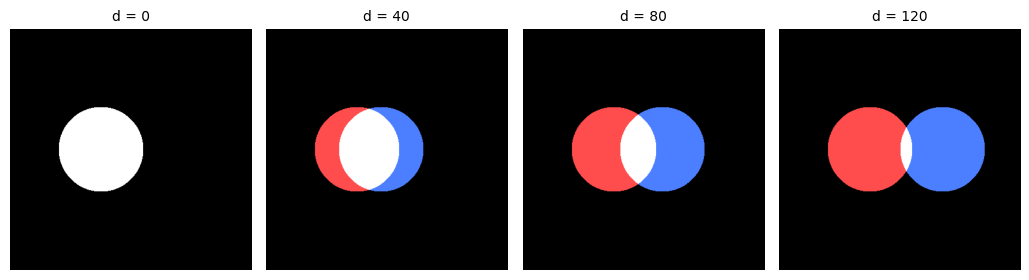

In [27]:
# === SOLUCION Ejercicio 5.1, relacion entre ambos indices y visualizacion ===
print(f"{'despl.':>8s}{'IoU':>9s}{'Dice':>9s}{'2*IoU/(1+IoU)':>16s}")
for d in [0, 40, 80, 120, 140]:
    B = circulo(150 + d)
    inter, union = (A & B).sum(), (A | B).sum()
    iou = inter / union
    dice = 2 * inter / (A.sum() + B.sum())
    print(f"{d:8d}{iou:9.4f}{dice:9.4f}{2 * iou / (1 + iou):16.4f}")

vistas = []
for d in [0, 40, 80, 120]:
    B = circulo(150 + d)
    rgb = np.zeros((lado, lado, 3))
    rgb[A & B] = [1, 1, 1]        # interseccion en blanco
    rgb[A & ~B] = [1, 0.3, 0.3]   # solo A
    rgb[B & ~A] = [0.3, 0.5, 1]   # solo B
    vistas.append(rgb)
mostrar(vistas, [f"d = {d}" for d in [0, 40, 80, 120]], ancho=2.6)

**Comentario.** El IoU cae rapidamente con el desplazamiento y llega a cero cuando los circulos se separan, es decir, a un desplazamiento igual al diametro. Un dato que conviene retener es que el valor $0.5$ se alcanza con un desplazamiento cercano a la mitad del radio, un solapamiento que visualmente todavia parece bastante bueno. **El IoU es mas exigente que la impresion visual**, y por eso un valor de $0.5$, que suena mediocre, corresponde en la practica a una segmentacion aceptable en muchas tareas.

La identidad $\mathrm{Dice} = 2\,\mathrm{IoU}/(1+\mathrm{IoU})$ se verifica exactamente en todos los casos. Se obtiene sustituyendo $|A \cup B| = |A| + |B| - |A \cap B|$ en ambas definiciones. Al ser una funcion monotona creciente de IoU, **ambos indices ordenan igual cualquier conjunto de segmentaciones**: si un metodo supera a otro en IoU, tambien lo supera en Dice. La eleccion entre ambos es convencional, no tecnica. Dice es siempre mayor o igual y castiga menos los errores, lo que explica en parte su popularidad en imagen medica.

Una advertencia que conviene instalar desde ahora: estas medidas no son sensibles a la forma del error. Dos segmentaciones con el mismo IoU pueden fallar de maneras muy distintas, una perdiendo un objeto completo y otra equivocandose un pixel a lo largo de todo el contorno.

**Comentario.** La conjuncion de criterios es el patron mas util de esta seccion: cada condicion se expresa por separado como una mascara y luego se combinan con operaciones logicas, lo que mantiene el codigo legible y permite inspeccionar cada criterio de manera independiente cuando algo falla. En la segmentacion por color del proximo cuaderno se usara exactamente esta estructura, combinando condiciones sobre matiz, saturacion y valor con varios AND encadenados.

El conteo revela un detalle que conviene notar: la suma de los objetos de ambas regiones puede superar el total de la imagen completa. La causa es que la frontera geometrica corta monedas por la mitad, y cada mitad se cuenta como un objeto en su respectiva region. **Una operacion puntual no sabe nada de objetos**, solo de pixeles, de modo que recortar una region no respeta los limites de las estructuras que contiene. Cuando eso importa, la region de interes debe aplicarse despues del etiquetado, filtrando por la posicion del centroide de cada objeto en lugar de por la mascara de pixeles.

El filtro por area dentro de la funcion de conteo cumple el mismo papel que en el ejercicio 2.2: sin el, cada fragmento residual del umbralizado se contabilizaria como un objeto.

---

# Subtema 6. Mezcla alfa y transicion cruzada

## Blending

La mezcla alfa es el blending del subtema 1 mirado como una operacion de composicion:

$$C_\alpha = \alpha F + (1-\alpha) B$$

donde $F$ es el primer plano, $B$ el fondo y $\alpha$ la cobertura o transparencia. Recorrer $\alpha$ de 0 a 1 genera una **transicion cruzada**, que es la forma mas simple de fundido entre dos imagenes y la base de las transiciones de video.

Cuando $\alpha$ es un escalar, la mezcla es global y afecta a toda la imagen por igual. Cuando $\alpha$ varia con la posicion, como en el subtema 4, la misma formula produce composiciones locales. Es una sola operacion con dos lecturas.

### Ejercicio 6.1. Transicion cruzada

**Enunciado.** Construya una transicion cruzada entre `data.chelsea()` y `data.coffee()`, recortadas al mismo tamano, evaluando $C_\alpha = \alpha F + (1-\alpha) B$ para $\alpha \in \{0,\ 0.25,\ 0.5,\ 0.75,\ 1\}$. Verifique que el rango del resultado se mantiene valido. Construya ademas una transicion espacial, en la que $\alpha$ varie linealmente a lo largo de las columnas en lugar de ser constante, y compare ambos resultados.

#### SOLUCION — Ejercicio 6.1

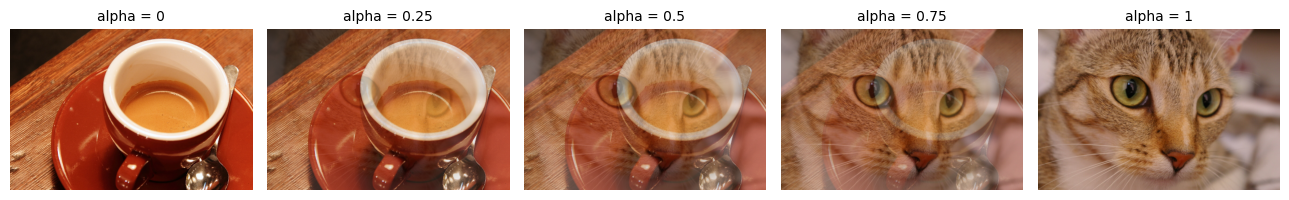

alpha = 0.00   rango = [0.000, 1.000]
alpha = 0.25   rango = [0.000, 0.937]
alpha = 0.50   rango = [0.000, 0.898]
alpha = 0.75   rango = [0.000, 0.863]
alpha = 1.00   rango = [0.000, 0.906]


In [28]:
# === SOLUCION Ejercicio 6.1, transicion temporal ===
F = util.img_as_float(data.chelsea())
B = util.img_as_float(data.coffee())

# Ambas imagenes deben tener el mismo tamano para operar pixel a pixel
h = min(F.shape[0], B.shape[0]); w = min(F.shape[1], B.shape[1])
F, B = F[:h, :w], B[:h, :w]

alphas = [0, 0.25, 0.5, 0.75, 1]
mezclas = [a * F + (1 - a) * B for a in alphas]

mostrar(mezclas, [f"alpha = {a}" for a in alphas], ancho=2.6)

for a, g in zip(alphas, mezclas):
    print(f"alpha = {a:4.2f}   rango = [{g.min():.3f}, {g.max():.3f}]")

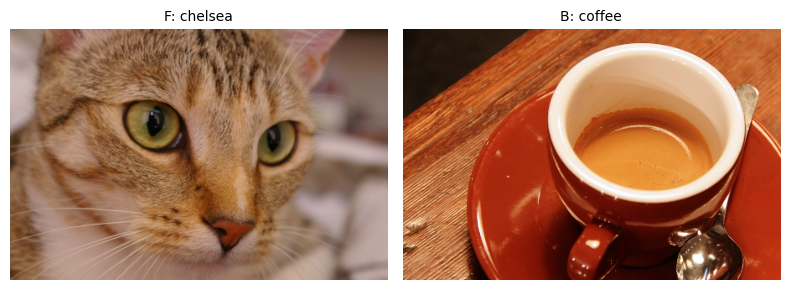

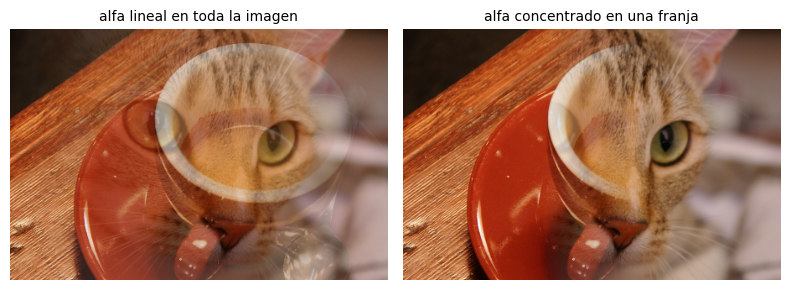

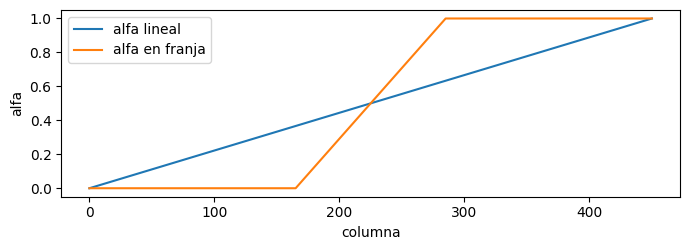

In [29]:
# === SOLUCION Ejercicio 6.1, transicion espacial ===
# alfa varia con la columna: 0 a la izquierda, 1 a la derecha
rampa = np.linspace(0, 1, w)[None, :, None]      # forma (1, w, 1) para difundir sobre canales
transicion_espacial = rampa * F + (1 - rampa) * B

# Version con la transicion concentrada en una franja central
centro, ancho_franja = w // 2, 120
x = np.arange(w)
rampa2 = np.clip((x - centro + ancho_franja / 2) / ancho_franja, 0, 1)[None, :, None]
transicion_franja = rampa2 * F + (1 - rampa2) * B

mostrar([F, B], ["F: chelsea", "B: coffee"], ancho=4.0)
mostrar([transicion_espacial, transicion_franja],
        ["alfa lineal en toda la imagen", "alfa concentrado en una franja"], ancho=4.0)

plt.figure(figsize=(7, 2.6))
plt.plot(rampa.ravel(), label="alfa lineal")
plt.plot(rampa2.ravel(), label="alfa en franja")
plt.xlabel("columna"); plt.ylabel("alfa"); plt.legend(); plt.tight_layout(); plt.show()

**Comentario.** El rango del resultado se mantiene en $[0,1]$ para todo $\alpha$, por la misma razon del ejercicio 1.3: es una combinacion convexa.

La comparacion entre las dos transiciones espaciales muestra que lo unico que cambia es el perfil de $\alpha$. Con la rampa lineal, cada columna contiene una mezcla distinta y ninguna de las dos imagenes se ve nunca limpia; con la franja, cada imagen se conserva intacta en su mitad y la mezcla se confina a una banda estrecha. Esa segunda variante es la que se usa al unir dos fotografias en una panoramica, donde el objetivo es que la costura no se note: una transicion abrupta produce un borde visible y una transicion demasiado ancha produce imagenes fantasma, de modo que el ancho de la franja es el parametro de ajuste.

Notese que la mezcla alfa, sea global o espacial, sigue siendo una operacion puntual: el valor de salida en cada pixel depende solo de los valores de entrada en ese pixel y del peso local. Ninguna vecindad interviene, y por eso todas las advertencias del subtema 1 sobre correspondencia geometrica siguen vigentes. Mezclar dos imagenes que no observan la misma escena desde el mismo punto de vista produce un resultado sin sentido fisico, por muy suave que sea la transicion.